In [1]:
.libPaths()

[1] "/fast/home/y/ykazci/R/x86_64-unknown-linux-gnu-library/4.3"               
[2] "/gnu/store/5bw3l7k55lrjdcvgmb3q7c2vh7k61liy-profile/site-library"         
[3] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [2]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [3]:
# set lib path to my seurat-signac env:

my_seurat_env <- "/home/ykazci/.guix-extra-profiles/seurat_signac/my_seurat_signac/site-library"

In [4]:
.libPaths(new = my_seurat_env, include.site = FALSE)

In [5]:
.libPaths()

[1] "/gnu/store/qrl2b62ysyphhhb5hahqsy67p8dql4w9-profile/site-library"         
[2] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [6]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [7]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t




In [8]:
library(Signac)

In [9]:
here::here('r_objects') |> list.files()

[1] "GeneExpressionMatrix.RDS"         "PeakMatrix.RDS"                  
[3] "mannens_et_al_seurat_obj.RDS"     "pca_atac_by_bpcells_package.RDS" 
[5] "pca_rna_by_bpcells_package.RDS"   "umap_atac_by_bpcells_package.RDS"
[7] "umap_rna_by_bpcells_package.RDS"

In [10]:
mannens_et_al_seurat <- readRDS(here::here('r_objects', 'mannens_et_al_seurat_obj.RDS'))

In [11]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks

In [12]:
pca_rna <- readRDS(here::here('r_objects', 'pca_rna_by_bpcells_package.RDS'))

In [13]:
pca_rna |> head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
10X280_1:CAGATTCAGCAGCTCA,11.68507,2.8045455,-4.018724,-0.3964521,-9.685796,-0.424207,0.06078384,-1.3796543,3.749118,1.4704291,...,0.4096793,2.521119332,0.3161485,-0.1337447,0.2925877,-1.0550482,0.2190711,-0.1039452,0.7484504,0.06040559
10X365_2:ACCAATATCAATGACC,12.96908,1.7452696,-2.034712,3.4330930,-9.619656,3.448072,-3.75869715,-0.3612605,4.506057,1.2168143,...,1.5880896,0.840545613,0.8882513,0.8240609,-0.7613740,-0.1219777,1.3404239,1.0325178,0.7608163,1.47329909
10X365_2:ATGGTGCGTCACCTAT,10.65661,0.4398173,-2.115898,-1.2366195,-9.001465,3.212608,-1.89405732,-0.3588529,1.524232,1.0741543,...,1.4804168,1.874840097,1.0724807,-0.5316255,-0.1509001,-0.3689890,0.3150829,1.9912154,-0.1946973,-0.30108498
10X280_1:ACACCTTGTCATTAGG,12.70601,2.5122955,-2.680215,1.4662002,-9.427586,1.998881,-0.91693096,-0.5826290,3.280597,2.1258360,...,0.9493900,0.005232236,0.5080041,-0.2739361,-0.5236287,1.0120951,0.1606706,-0.4287535,0.7905107,-0.36941142
10X406_1:TATCGCGAGGCTTAAC,13.58802,2.6166203,-1.836761,2.8251702,-9.062447,5.760414,-3.05728156,-0.5401609,3.986806,0.7846181,...,0.7464443,-0.306289810,0.2132332,-0.0783976,0.1207450,1.1132732,-0.6757007,-0.2133199,-0.6403831,-0.07571696
10X280_1:ACCTTGCTCCGTAAAC,13.59383,2.8637986,-4.314536,1.5315912,-8.463817,3.054717,-3.78745619,0.4027217,3.926991,2.3936043,...,2.1182564,1.226891828,1.3990760,-1.5416426,-1.1007787,0.7343006,0.8004268,-0.3599274,-0.0799788,1.24976894


In [14]:
identical(rownames(pca_rna), colnames(mannens_et_al_seurat))

[1] TRUE

In [15]:
mannens_et_al_seurat[['pca']] <- CreateDimReducObject(embeddings = pca_rna, assay = 'RNA', key = 'pca_')

In [16]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 1 dimensional reduction calculated: pca

In [17]:
pca_atac <- readRDS(here::here('r_objects', 'pca_atac_by_bpcells_package.RDS'))

In [18]:
pca_atac |> head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
10X280_1:CAGATTCAGCAGCTCA,164.24896,81.05230,-39.32921,2.580737,-195.02320,-34.86484,100.39635,-40.69173,50.12320,159.69269
10X365_2:ACCAATATCAATGACC,147.25564,65.10221,-34.33611,2.348611,-178.66610,-38.86885,109.05191,-40.25039,20.02558,163.49469
10X365_2:ATGGTGCGTCACCTAT,164.96763,73.46412,-34.88540,3.720248,-184.76510,-39.42978,109.56832,-45.20101,16.74008,169.81372
10X280_1:ACACCTTGTCATTAGG,163.99640,78.00608,-39.79235,4.167186,-189.28987,-36.84049,101.09625,-43.77914,36.24521,157.43050
10X406_1:TATCGCGAGGCTTAAC,75.05646,41.27165,-18.51752,3.103557,-91.04797,-16.53701,41.79393,-33.97893,16.77703,68.34107
10X280_1:ACCTTGCTCCGTAAAC,171.60557,78.74242,-38.36448,5.873144,-197.22008,-42.46081,106.96846,-44.44478,38.34260,168.15236


In [19]:
identical(rownames(pca_atac), colnames(mannens_et_al_seurat))

[1] TRUE

In [20]:
mannens_et_al_seurat[['pca_atac']] <- CreateDimReducObject(embeddings = pca_atac, assay = 'peaks', key = 'pcaAtac_')

In [21]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 2 dimensional reductions calculated: pca, pca_atac

In [22]:
my_colours = c(
    "#5A5156FF", "#F6222EFF", "#FE00FAFF", "#16FF32FF",
    "#3283FEFF", "#FEAF16FF", "#B00068FF", "#1CFFCEFF", "#90AD1CFF",
    "#2ED9FFFF", "#DEA0FDFF", "#AA0DFEFF", "#F8A19FFF", "#325A9BFF",
    "#C4451CFF", "#1C8356FF", "#85660DFF", "#B10DA1FF", "#FBE426FF",
    "#1CBE4FFF", "#FA0087FF", "#FC1CBFFF", "#F7E1A0FF", "#C075A6FF",
    "#782AB6FF", "#AAF400FF", "#BDCDFFFF", "#822E1CFF", "#B5EFB5FF",
    "#7ED7D1FF", "#1C7F93FF", "#D85FF7FF", "#683B79FF", "#66B0FFFF",
    "#3B00FBFF"
)

In [23]:
options(repr.plot.width = 15, repr.plot.height = 7)

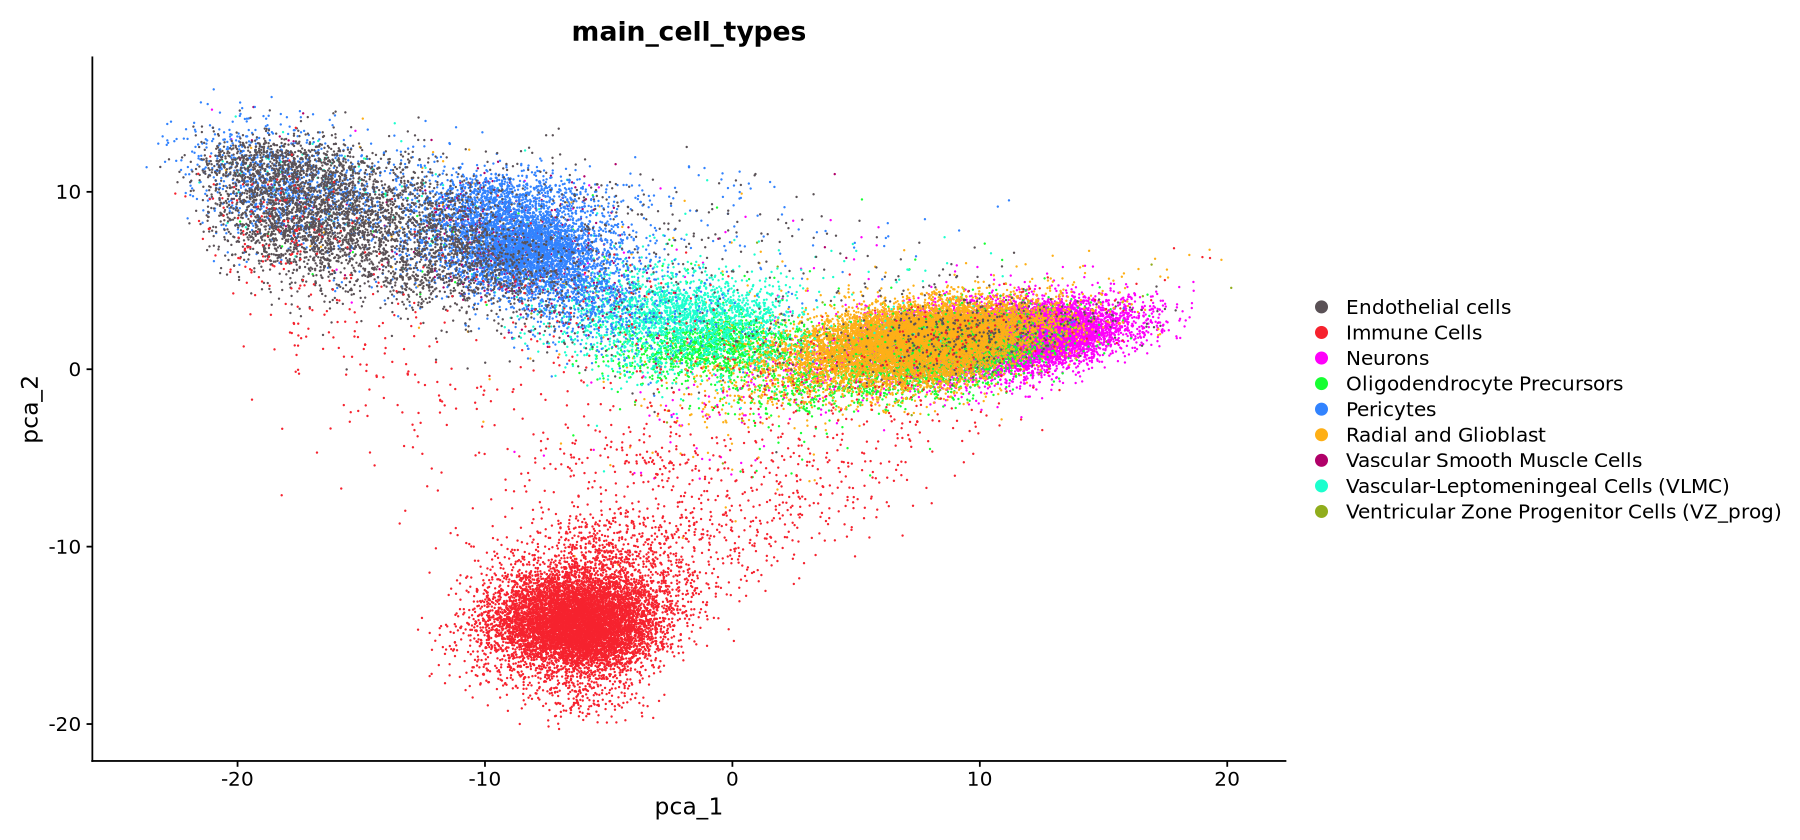

In [24]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'pca', group.by = 'main_cell_types', cols = my_colours)

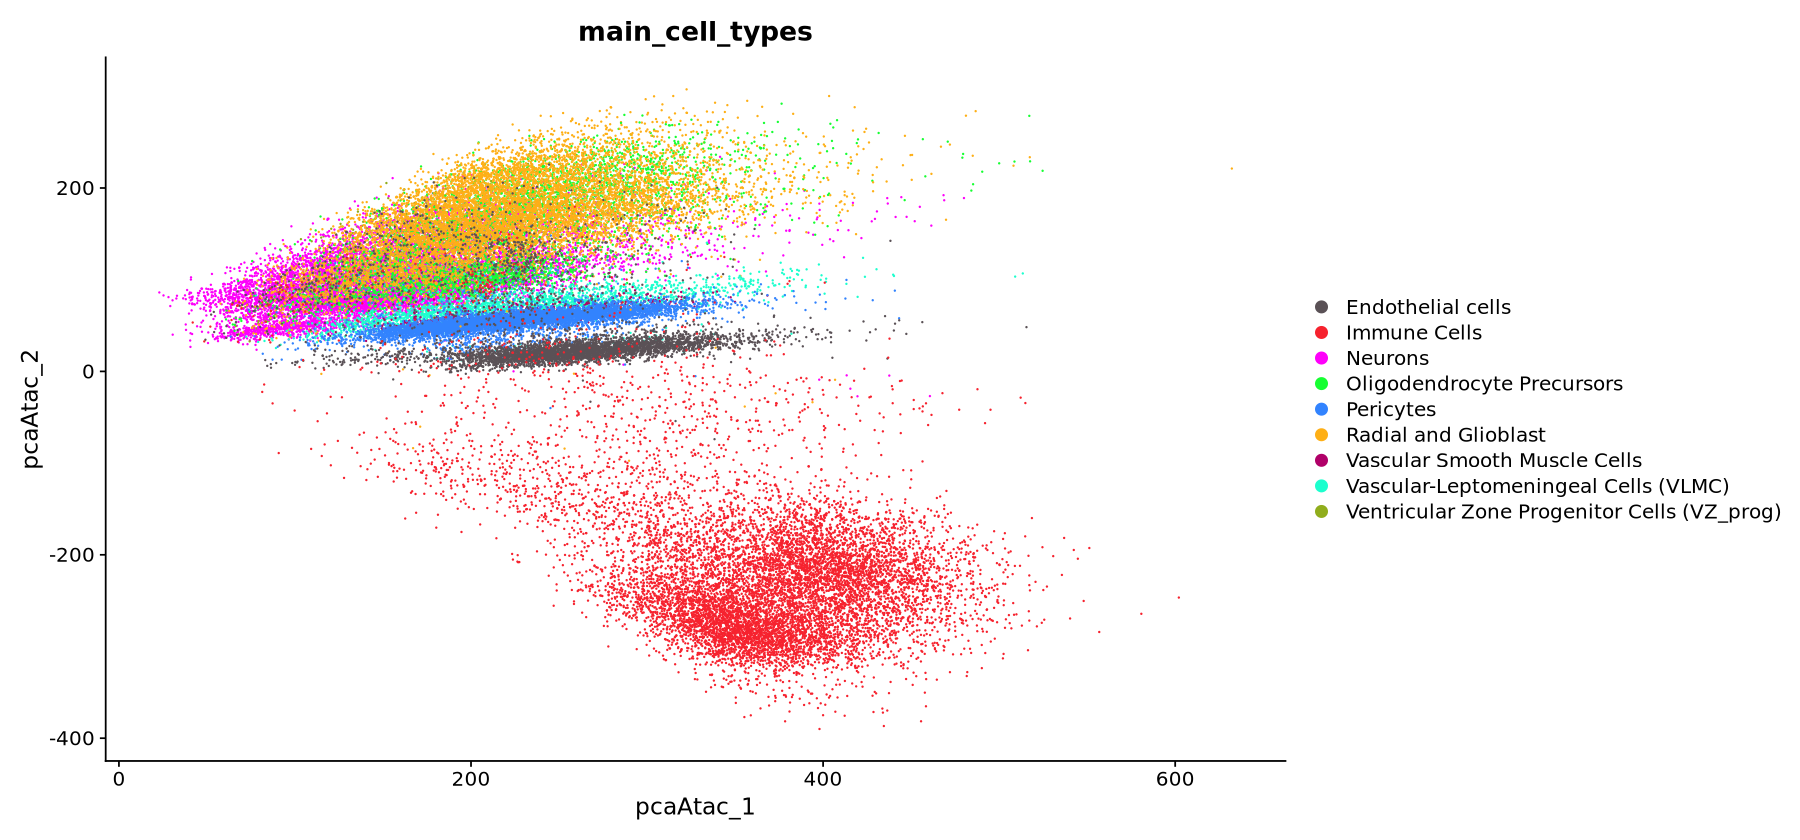

In [25]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'pca_atac', group.by = 'main_cell_types', cols = my_colours)

In [26]:
# add umaps computed by bpcells package:

umap_rna <- readRDS(here::here('r_objects', 'umap_rna_by_bpcells_package.RDS'))

In [27]:
# add umaps computed by bpcells package:

umap_atac <- readRDS(here::here('r_objects', 'umap_atac_by_bpcells_package.RDS'))

In [28]:
identical(rownames(umap_rna), rownames(umap_atac))

[1] TRUE

In [29]:
identical(colnames(mannens_et_al_seurat), rownames(umap_atac))

[1] TRUE

In [30]:
mannens_et_al_seurat[['umap_rna']] <- CreateDimReducObject(embeddings = umap_rna, assay = 'RNA', key = 'umapRNA_')

In [31]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 3 dimensional reductions calculated: pca, pca_atac, umap_rna

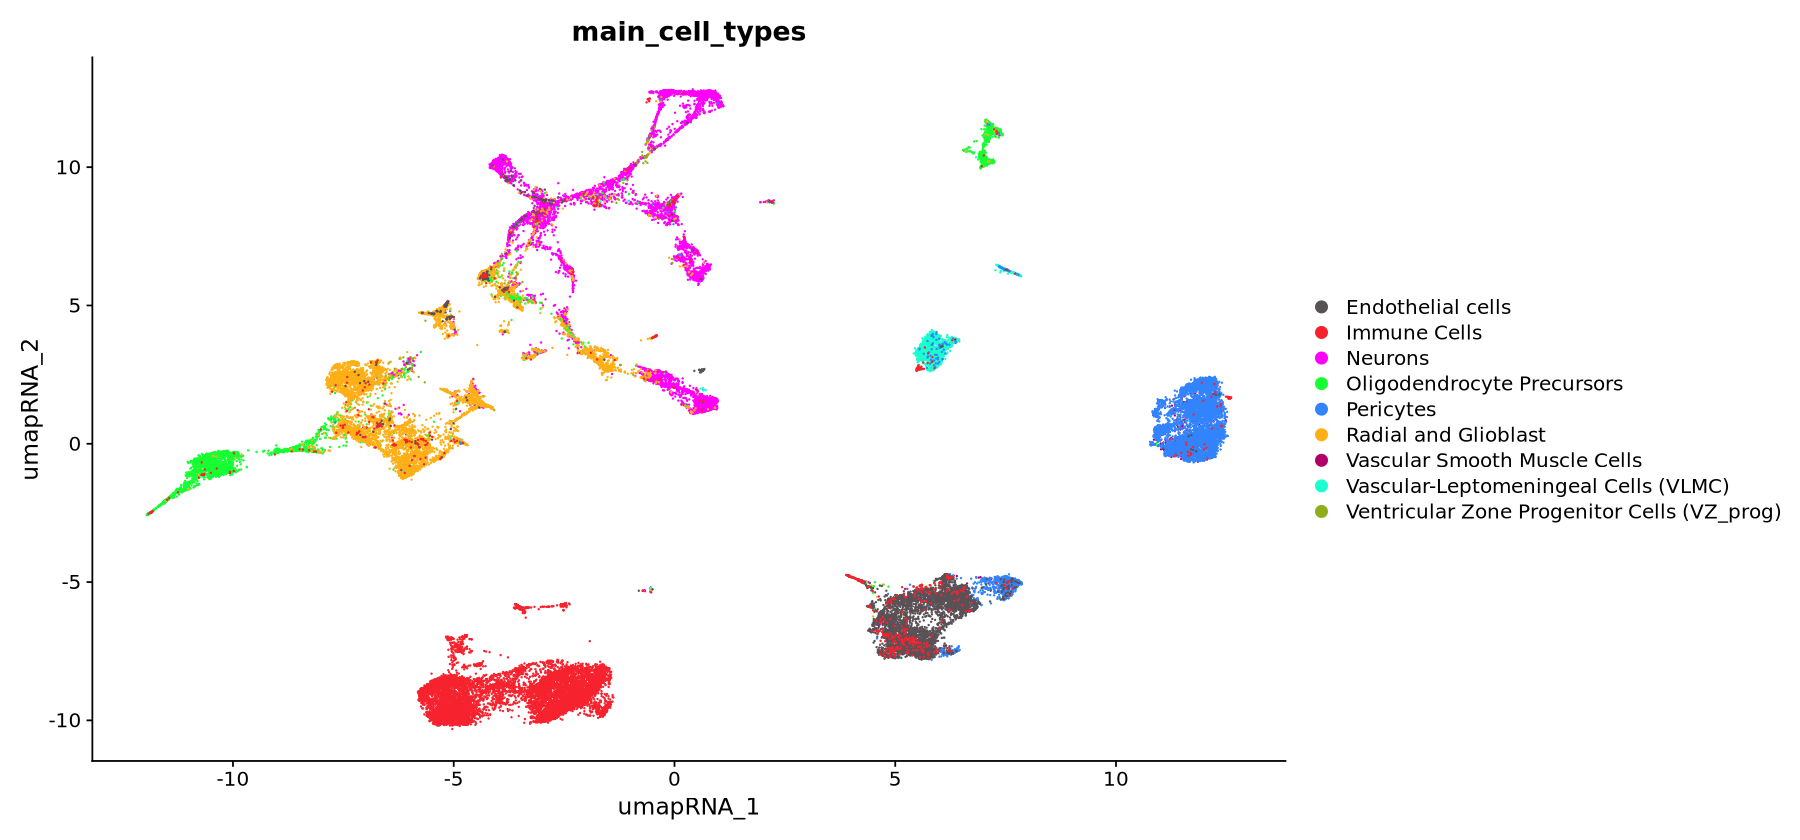

In [32]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'umap_rna', group.by = 'main_cell_types', cols = my_colours)

In [33]:
mannens_et_al_seurat[['umap_atac']] <- CreateDimReducObject(embeddings = umap_atac, assay = 'peaks', key = 'umapATAC_')

In [34]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 4 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac

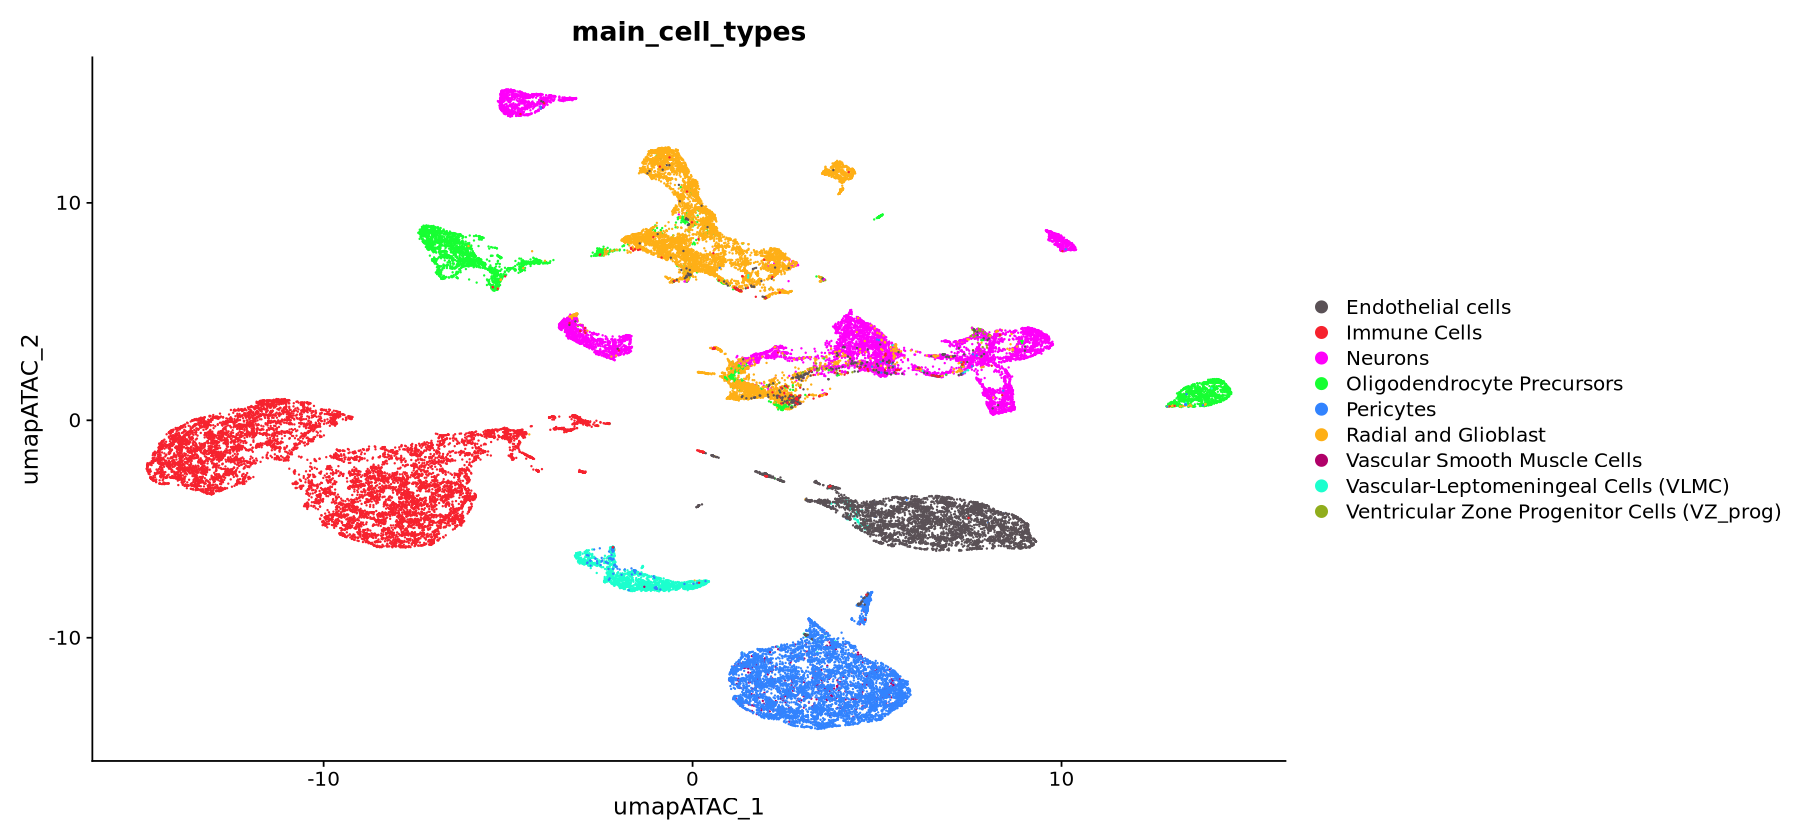

In [35]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'umap_atac', group.by = 'main_cell_types', cols = my_colours)

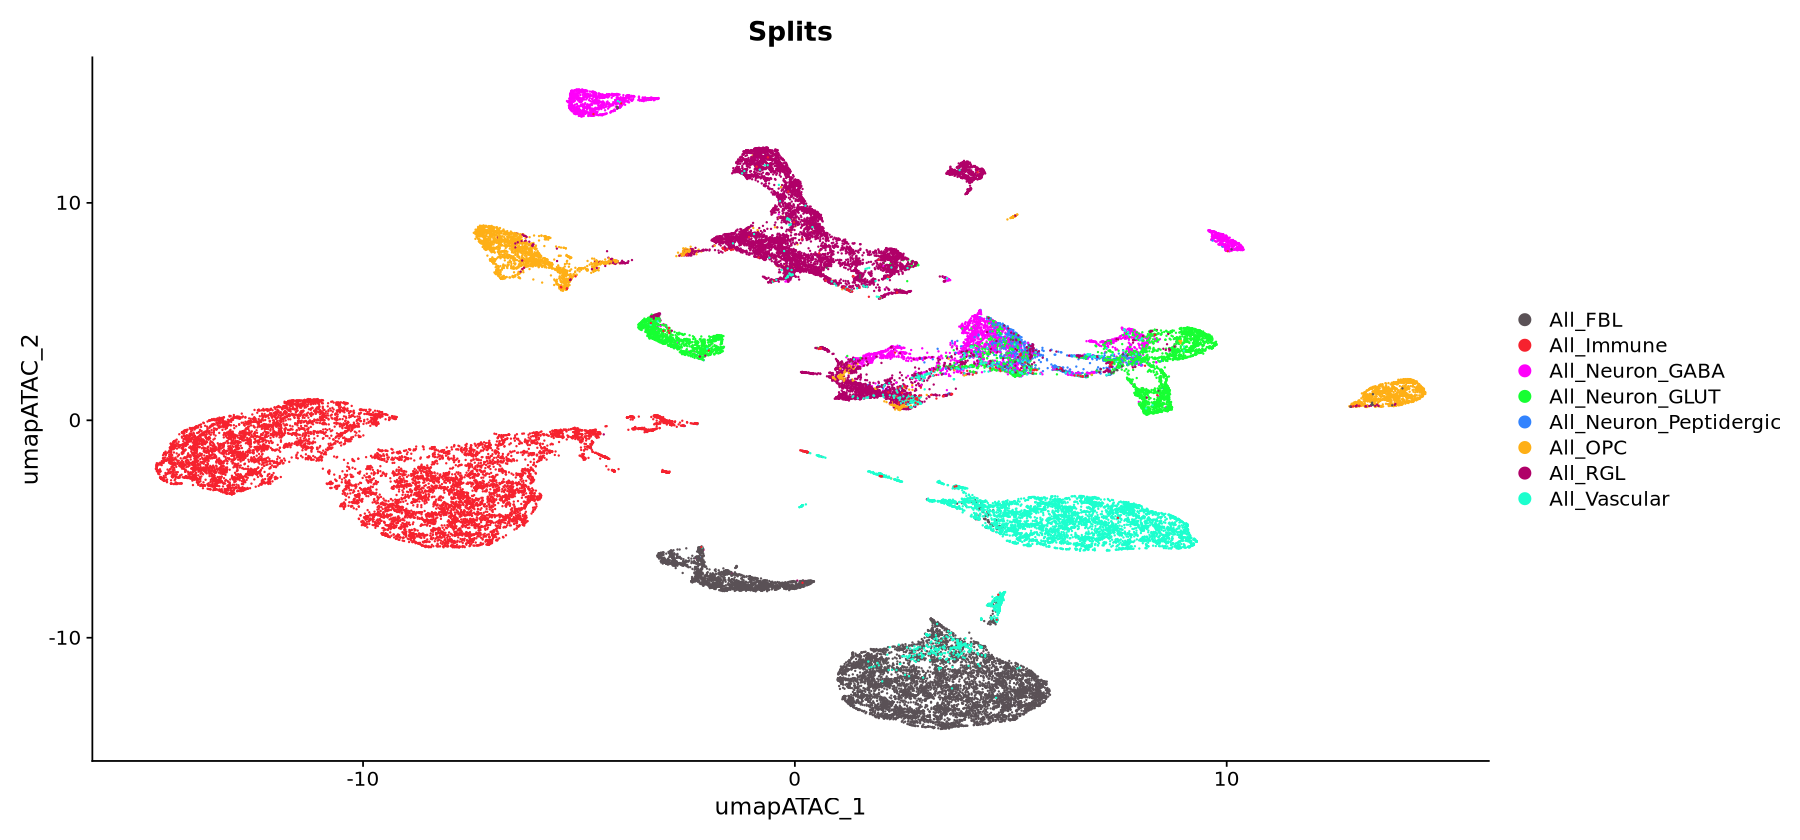

In [36]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'umap_atac', group.by = 'Splits', cols = my_colours)

Note: In later uses, modality.weightname = list('RNA.weight#, 'peaks.weight') should be used.

In [46]:
# build a joint neighbor graph using both assays
mannens_et_al_seurat <- FindMultiModalNeighbors(
  object = mannens_et_al_seurat,
  reduction.list = list("pca", "pca_atac"), 
  dims.list = list(1:50, 1:10), # bpcells atac PC firts component does not correlate with total counts therefore include all components.
  modality.weight.name = "joint.weight",
  verbose = TRUE
)

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Warning message in FindMultiModalNeighbors(object = mannens_et_al_seurat, reduction.list = list("pca", :
"The number of provided modality.weight.name is not equal to the number of modalities. RNA.weight peaks.weight are used to store the modality weights"
Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph



In [62]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 4 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac

In [63]:
mannens_et_al_seurat |> Neighbors()

[1] "weighted.nn"

In [65]:
mannens_et_al_seurat <- RunUMAP(
  object = mannens_et_al_seurat,
  nn.name = "weighted.nn",
  assay = "RNA",
  reduction.name = 'joint_umap',
  verbose = TRUE
)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
15:22:41 UMAP embedding parameters a = 0.9922 b = 1.112

15:22:42 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

15:22:42 1 smooth knn distance failures

15:22:45 Initializing from normalized Laplacian + noise (using RSpectra)

15:22:51 Commencing optimization for 200 epochs, with 1430524 positive edges

15:23:23 Optimization finished



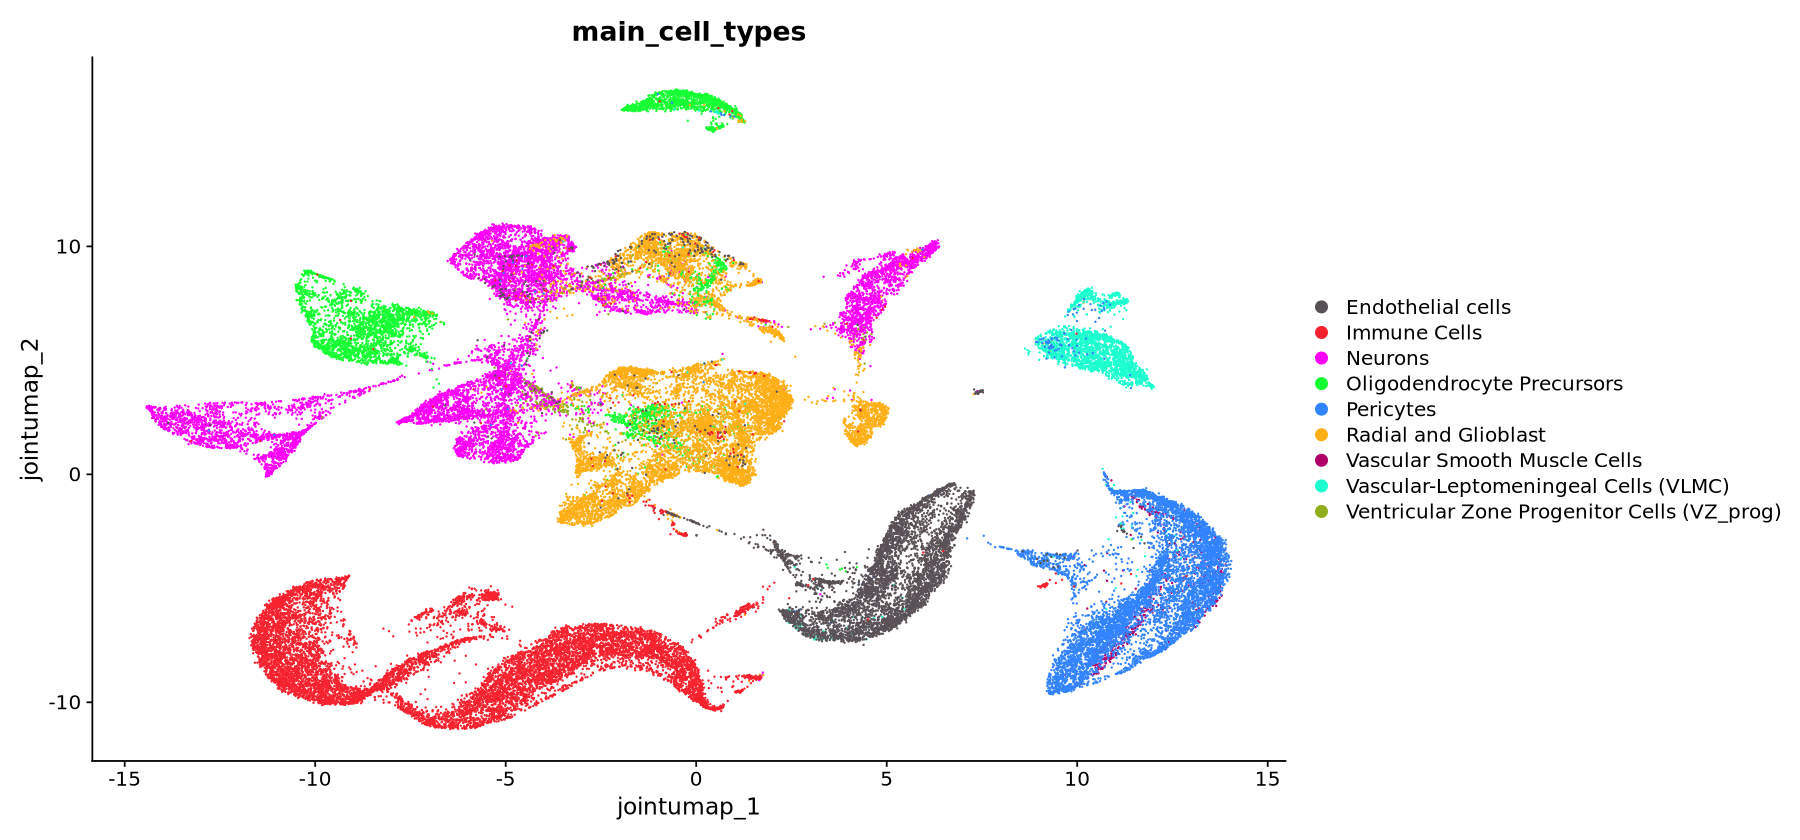

In [66]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'joint_umap', group.by = 'main_cell_types', cols = my_colours)

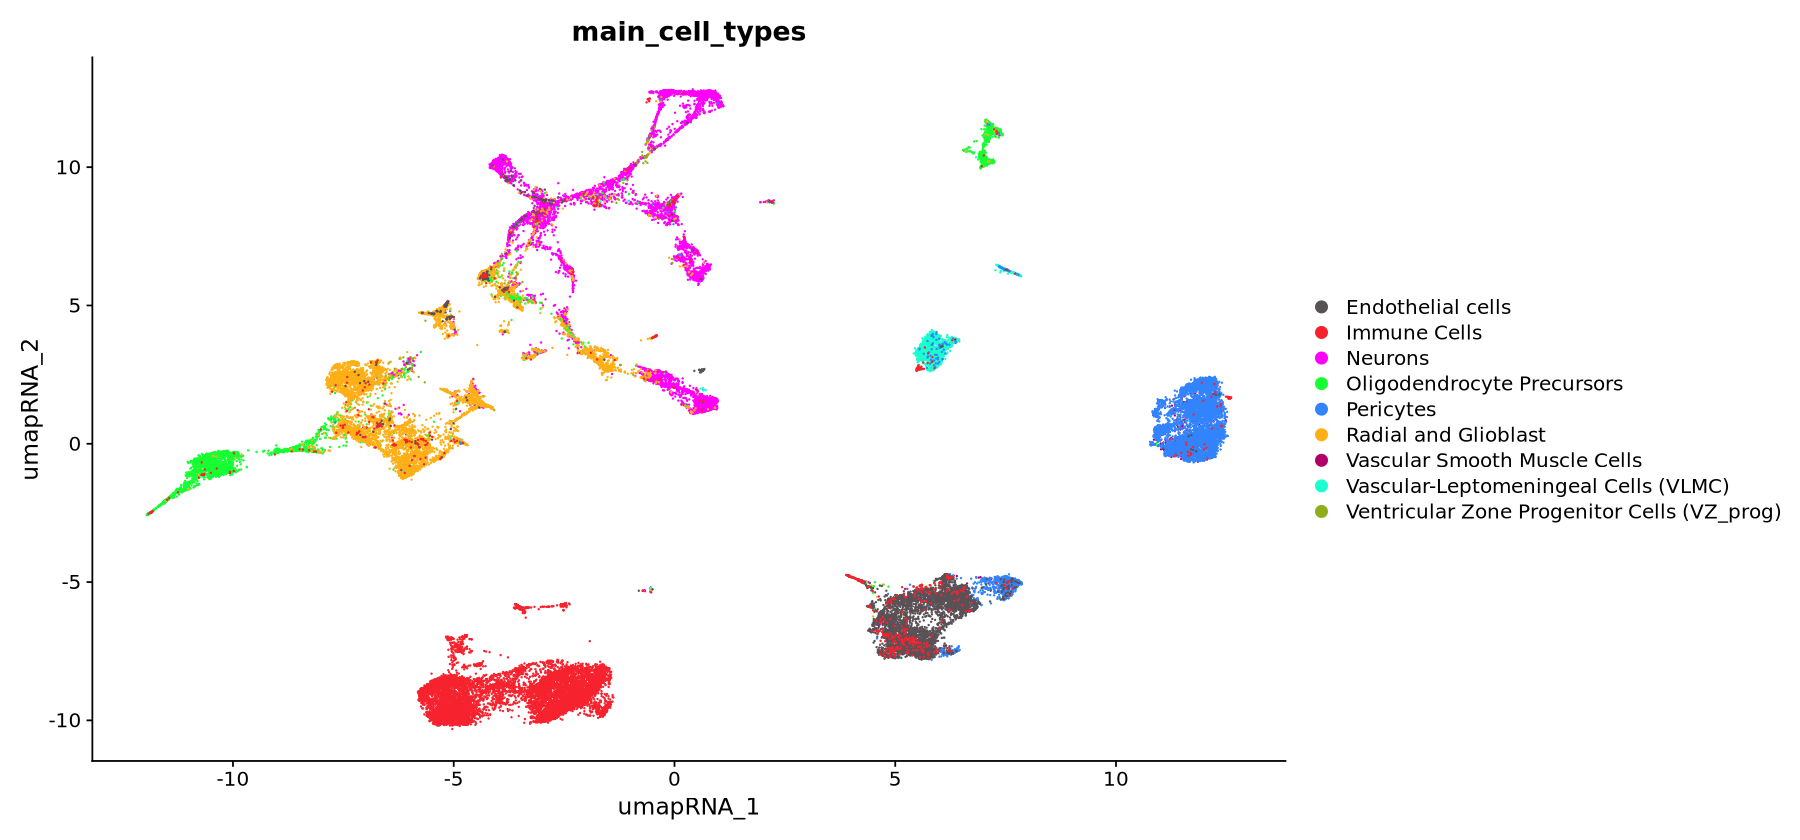

In [67]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'umap_rna', group.by = 'main_cell_types', cols = my_colours)

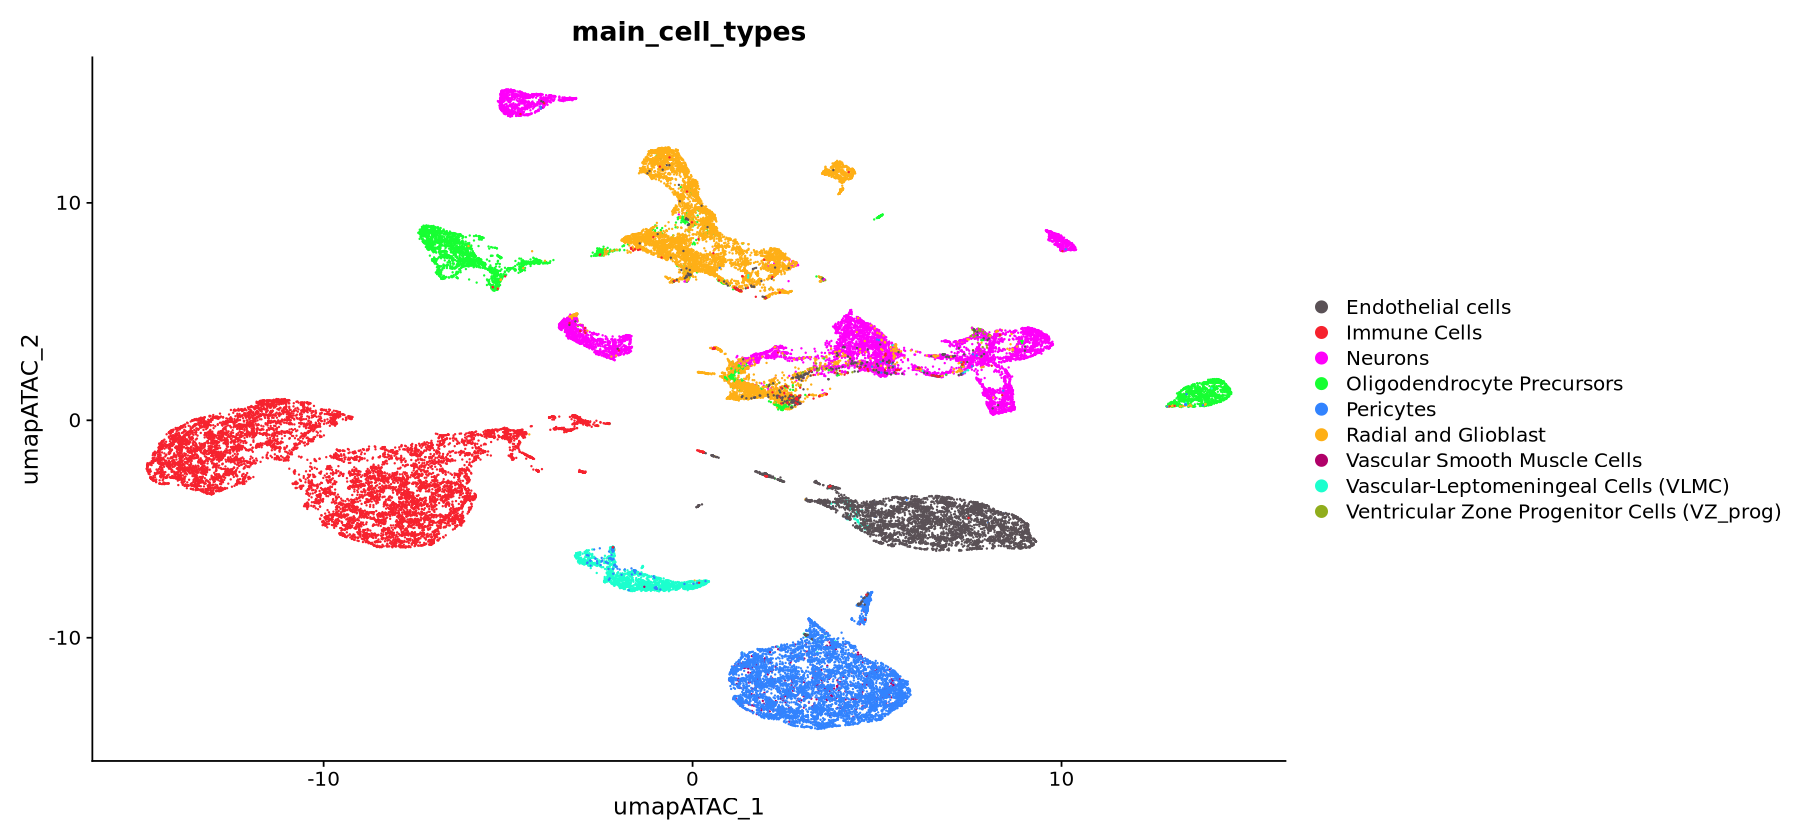

In [68]:
DimPlot(object = mannens_et_al_seurat, dims = 1:2, reduction = 'umap_atac', group.by = 'main_cell_types', cols = my_colours)

In [69]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 5 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap

In [72]:
# I downloaded some packages to my seurat guix profile and now 
# nned to add the library path again:

.libPaths(new = my_seurat_env, include.site = FALSE)

In [73]:
library(motifmatchr)

In [74]:
library(JASPAR2020)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg19)


Attaching package: 'TFBSTools'


The following object is masked from 'package:Matrix':

    Matrix


Loading required package: BSgenome

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following object is masked from 'package:SeuratObject':

    intersect


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: 'S4Vectors'


The following objects are masked from 'package:Matrix':



In [75]:
# extract position frequency matrices for the motifs
pwm <- getMatrixSet(
  x = JASPAR2020,
  opts = list(species = 9606, all_versions = FALSE)
)

In [76]:
pwm |> head()

PFMatrixList of length 6
names(6): MA0030.1 MA0031.1 MA0051.1 MA0057.1 MA0059.1 MA0066.1

In [79]:
mannens_et_al_seurat@assays$peaks

ChromatinAssay data with 405121 features for 49470 cells
Variable features: 101285 
Genome: 
Annotation present: TRUE 
Motifs present: FALSE 
Fragment files: 0 

In [81]:
# my genome is hg38.

detach('package:BSgenome.Hsapiens.UCSC.hg19')

In [82]:
# I downloaded some packages to my seurat guix profile and now 
# nned to add the library path again:

.libPaths(new = my_seurat_env, include.site = FALSE)

In [83]:
library(BSgenome.Hsapiens.UCSC.hg38)

In [84]:
# add motif information:

mannens_et_al_seurat <- AddMotifs(mannens_et_al_seurat, genome = BSgenome.Hsapiens.UCSC.hg38, assay = 'peaks', pfm = pwm)

Building motif matrix

Finding motif positions

Creating Motif object



In [88]:
mannens_et_al_seurat@assays$peaks

ChromatinAssay data with 405121 features for 49470 cells
Variable features: 101285 
Genome: 
Annotation present: TRUE 
Motifs present: TRUE 
Fragment files: 0 

In [93]:
mannens_et_al_seurat@assays$peaks@motifs@motif.names |> class()

[1] "list"

In [97]:
mannens_et_al_seurat@assays$peaks@motifs@motif.names |> unlist(use.names = FALSE) |> sort()

[1] "ALX3"                "ARGFX"               "ARNT2"              
  [4] "ARNT::HIF1A"         "ASCL1"               "ASCL1(var.2)"       
  [7] "ATF2"                "ATF3"                "ATF4"               
 [10] "ATF6"                "ATF7"                "ATOH1(var.2)"       
 [13] "ATOH7"               "BACH1"               "BACH2"              
 [16] "BACH2(var.2)"        "BARHL1"              "BARHL2"             
 [19] "BARX1"               "BARX2"               "BATF"               
 [22] "BATF3"               "BATF::JUN"           "BCL6"               
 [25] "BCL6B"               "BHLHA15(var.2)"      "BHLHE22"            
 [28] "BHLHE22(var.2)"      "BHLHE23"             "BHLHE40"            
 [31] "BHLHE41"             "BSX"                 "CDX1"               
 [34] "CDX2"                "CDX4"                "CEBPA"              
 [37] "CEBPB"               "CEBPD"               "CEBPE"              
 [40] "CEBPG"               "CEBPG(var.2)"        "CENPB"              
 [43] "CLOCK"               "CREB1"               "CREB3"              
 [46] "CREB3L1"             "CREB3L4"             "CREB3L4(var.2)"     
 [49] "CREM"                "CTCF"                "CTCFL"              
 [52] "CUX1"                "CUX2"                "DBP"                
 [55] "DLX5"                "DLX6"                "DMRT3"              
 [58] "DMRTA2"              "DMRTC2"              "DPRX"               
 [61] "DRGX"                "DUX4"                "DUXA"               
 [64] "E2F1"                "E2F2"                "E2F3"               
 [67] "E2F4"                "E2F6"                "E2F7"               
 [70] "E2F8"                "EBF1"                "EBF3"               
 [73] "EGR1"                "EGR2"                "EGR3"               
 [76] "EGR4"                "EHF"                 "ELF1"               
 [79] "ELF2"                "ELF3"                "ELF4"               
 [82] "ELF5"                "ELK1"                "ELK3"               
 [85] "ELK4"                "EMX1"                "EMX2"               
 [88] "EN1"                 "EN2"                 "EOMES"              
 [91] "ERF"                 "ERG"                 "ESR1"               
 [94] "ESR2"                "ESRRA"               "ESRRB"              
 [97] "ESX1"                "ETS1"                "ETS2"               
[100] "ETV1"                "ETV2"                "ETV3"               
[103] "ETV4"                "ETV5"                "ETV6"               
[106] "EVX1"                "EVX2"                "EWSR1-FLI1"         
[109] "FERD3L"              "FEV"                 "FIGLA"              
[112] "FLI1"                "FOS"                 "FOS::JUN"           
[115] "FOS::JUN(var.2)"     "FOS::JUNB"           "FOS::JUND"          
[118] "FOSB::JUN"           "FOSB::JUNB"          "FOSB::JUNB(var.2)"  
[121] "FOSL1"               "FOSL1::JUN"          "FOSL1::JUN(var.2)"  
[124] "FOSL1::JUNB"         "FOSL1::JUND"         "FOSL1::JUND(var.2)" 
[127] "FOSL2"               "FOSL2::JUN"          "FOSL2::JUN(var.2)"  
[130] "FOSL2::JUNB"         "FOSL2::JUNB(var.2)"  "FOSL2::JUND"        
[133] "FOSL2::JUND(var.2)"  "FOXA1"               "FOXA2"              
[136] "FOXA3"               "FOXB1"               "FOXC1"              
[139] "FOXC2"               "FOXD1"               "FOXD2"              
[142] "FOXE1"               "FOXF2"               "FOXG1"              
[145] "FOXH1"               "FOXI1"               "FOXK1"              
[148] "FOXK2"               "FOXL1"               "FOXN3"              
[151] "FOXO3"               "FOXO4"               "FOXO6"              
[154] "FOXP1"               "FOXP2"               "FOXP3"              
[157] "GABPA"               "GATA1"               "GATA1::TAL1"        
[160] "GATA2"               "GATA3"               "GATA4"              
[163] "GATA5"               "GATA6"               "GBX1"               
[166] "GBX2"                "GCM1"        

=======================================================================================================

Motif footprinting:

Now we can footprint any motif that we have positional information for. \
By default, this includes every instance of the motif in the genome. \
We can instead use the in.peaks = TRUE parameter to include only \
those motifs that fall inside a peak in the assay. The Footprint()\
function gathers all the required data and stores it in the assay. \
We can then plot the footprinted motifs using the PlotFootprint() function.

NOTE: Since I did not store the fragments inside the chromatin assay,\
the following footprinting function can not be applied for now. 

I will obtain the fragment files for thse cells and firstly try to\
use BPCells and ArchR workflows.

In [102]:
mannens_et_al_seurat |> saveRDS(here::here('r_objects', 'mannens_et_al_seurat_modified.RDS'))

In [103]:
ls()

[1] "atac_embedding"       "cca_result"           "cross_modal_matrix"  
 [4] "mannens_et_al_seurat" "my_colours"           "my_seurat_env"       
 [7] "pca_atac"             "pca_rna"              "pwm"                 
[10] "rna_embedding"        "umap_atac"            "umap_rna"

In [106]:
# Gather the footprinting information for a specific set of motifs:

In [107]:
# mannens_et_al_seurat <- Footprint(
#   object = mannens_et_al_seurat,
#   assay = 'peaks',
#   motif.name = c('BHLHE40', 'SOX2'),
#   genome = BSgenome.Hsapiens.UCSC.hg38
# )

In [118]:
mannens_et_al_seurat

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 5 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap

===========================================================================

Below, I try to manually implement ArchR's combined embedding generation function from LSI and PCA.

I will try to calculate weights for both reductions to be used in generation of joint embeddings.

I will also try to simply use equal weights for LSI and PCA as an alternative.

In [119]:
# I asked chatGPT to implement addCombinedDims function of ArchR to my atac and rna PC components (LSI and PCA):

In [120]:
# Firstly a function to calculate the weights of each PC component in both embeddings:

calculate_embedding_weights <- function(seuratObj, reducedDims) {
  # Compute total variance for each embedding
  variances <- sapply(reducedDims, function(dim_name) {
    embedding <- seuratObj@reductions[[dim_name]]@cell.embeddings
    sum(apply(embedding, 2, var))  # Sum of variances across dimensions
  })
  
  # Normalize weights (sum to 1)
  weights <- variances / sum(variances)
  
  return(weights)
}

In [121]:
dim_weights <- calculate_embedding_weights(seuratObj = mannens_et_al_seurat, reducedDims = c('pca', 'pca_atac'))

In [122]:
dim_weights

pca    pca_atac 
0.004925854 0.995074146

In [138]:
addCombinedDims_Seurat <- function(
  seuratObj = NULL, 
  name = "CombinedDims",
  reducedDims = NULL, 
  weightMethod = "variance",  # Choose: "variance", "eigen", "entropy"
  dimsToUse = NULL
){

  # Compute weights based on the chosen method
  if (weightMethod == "variance") {
    dimWeights <- calculate_embedding_weights(seuratObj, reducedDims)
  } else if (weightMethod == "eigen") {
    dimWeights <- calculate_eigen_weights(seuratObj, reducedDims)
  } else if (weightMethod == "entropy") {
    dimWeights <- calculate_entropy_weights(seuratObj, reducedDims)
  } else {
    stop("Invalid weightMethod. Choose from 'variance', 'eigen', or 'entropy'.")
  }

  # Normalize embeddings using computed weights
  combinedDims <- lapply(seq_along(reducedDims), function(x) {
    rD <- seuratObj@reductions[[reducedDims[x]]]@cell.embeddings

    if (!is.null(dimsToUse)) {
      rD <- rD[, dimsToUse, drop = FALSE]
    }

    cV <- apply(as.matrix(rD), 2, var)
    normV <- 1 / sqrt(sum(cV))
    rD * normV * dimWeights[x]
  })

  # Correct the way embeddings are combined
  combinedDims <- do.call(cbind, combinedDims)

  # Assign column names
  colnames(combinedDims) <- paste0('Combined', 1:ncol(combinedDims))
  
  # Store in Seurat Object
  seuratObj[[name]] <- CreateDimReducObject(
    embeddings = combinedDims,
    key = "Combined_",
    assay = DefaultAssay(seuratObj)
  )

  return(seuratObj)
}

In [139]:
test <- addCombinedDims_Seurat(seuratObj = mannens_et_al_seurat, reducedDims = c('pca', 'pca_atac'))

In [140]:
test

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 6 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap, CombinedDims

In [144]:
test@reductions$CombinedDims@cell.embeddings |> head()

,Combined_1,Combined_2,Combined_3,Combined_4,Combined_5,Combined_6,Combined_7,Combined_8,Combined_9,Combined_10,...,Combined_51,Combined_52,Combined_53,Combined_54,Combined_55,Combined_56,Combined_57,Combined_58,Combined_59,Combined_60
10X280_1:CAGATTCAGCAGCTCA,0.003059811,0.0007343881,-0.0010523284,-0.0001038135,-0.002536287,-0.0001110813,1.591664e-05,-3.612713e-04,0.0009817303,0.0003850412,...,0.6112976,0.3016584,-0.14637446,0.009604924,-0.7258324,-0.12975908,0.3736526,-0.1514455,0.18654725,0.5943402
10X365_2:ACCAATATCAATGACC,0.003396037,0.0004570100,-0.0005328023,0.0008989773,-0.002518968,0.0009028996,-9.842388e-04,-9.459837e-05,0.0011799398,0.0003186306,...,0.5480523,0.2422958,-0.12779126,0.008741002,-0.6649550,-0.14466112,0.4058667,-0.1498029,0.07453068,0.6084904
10X365_2:ATGGTGCGTCACCTAT,0.002790501,0.0001151690,-0.0005540613,-0.0003238167,-0.002357091,0.0008412419,-4.959710e-04,-9.396792e-05,0.0003991297,0.0002812741,...,0.6139724,0.2734169,-0.12983560,0.013845924,-0.6876541,-0.14674876,0.4077886,-0.1682280,0.06230282,0.6320084
10X280_1:ACACCTTGTCATTAGG,0.003327151,0.0006578606,-0.0007018315,0.0003839339,-0.002468674,0.0005234196,-2.401042e-04,-1.525651e-04,0.0008590453,0.0005566637,...,0.6103577,0.2903211,-0.14809818,0.015509330,-0.7044943,-0.13711203,0.3762575,-0.1629361,0.13489651,0.5859209
10X406_1:TATCGCGAGGCTTAAC,0.003558109,0.0006851787,-0.0004809676,0.0007397888,-0.002373059,0.0015084012,-8.005686e-04,-1.414446e-04,0.0010439706,0.0002054572,...,0.2793432,0.1536038,-0.06891803,0.011550741,-0.3388600,-0.06154703,0.1555476,-0.1264619,0.06244033,0.2543501
10X280_1:ACCTTGCTCCGTAAAC,0.003559631,0.0007499039,-0.0011297886,0.0004010569,-0.002216304,0.0007998970,-9.917695e-04,1.054552e-04,0.0010283075,0.0006267805,...,0.6386773,0.2930616,-0.14278395,0.021858519,-0.7340087,-0.15802957,0.3981125,-0.1654135,0.14270254,0.6258252


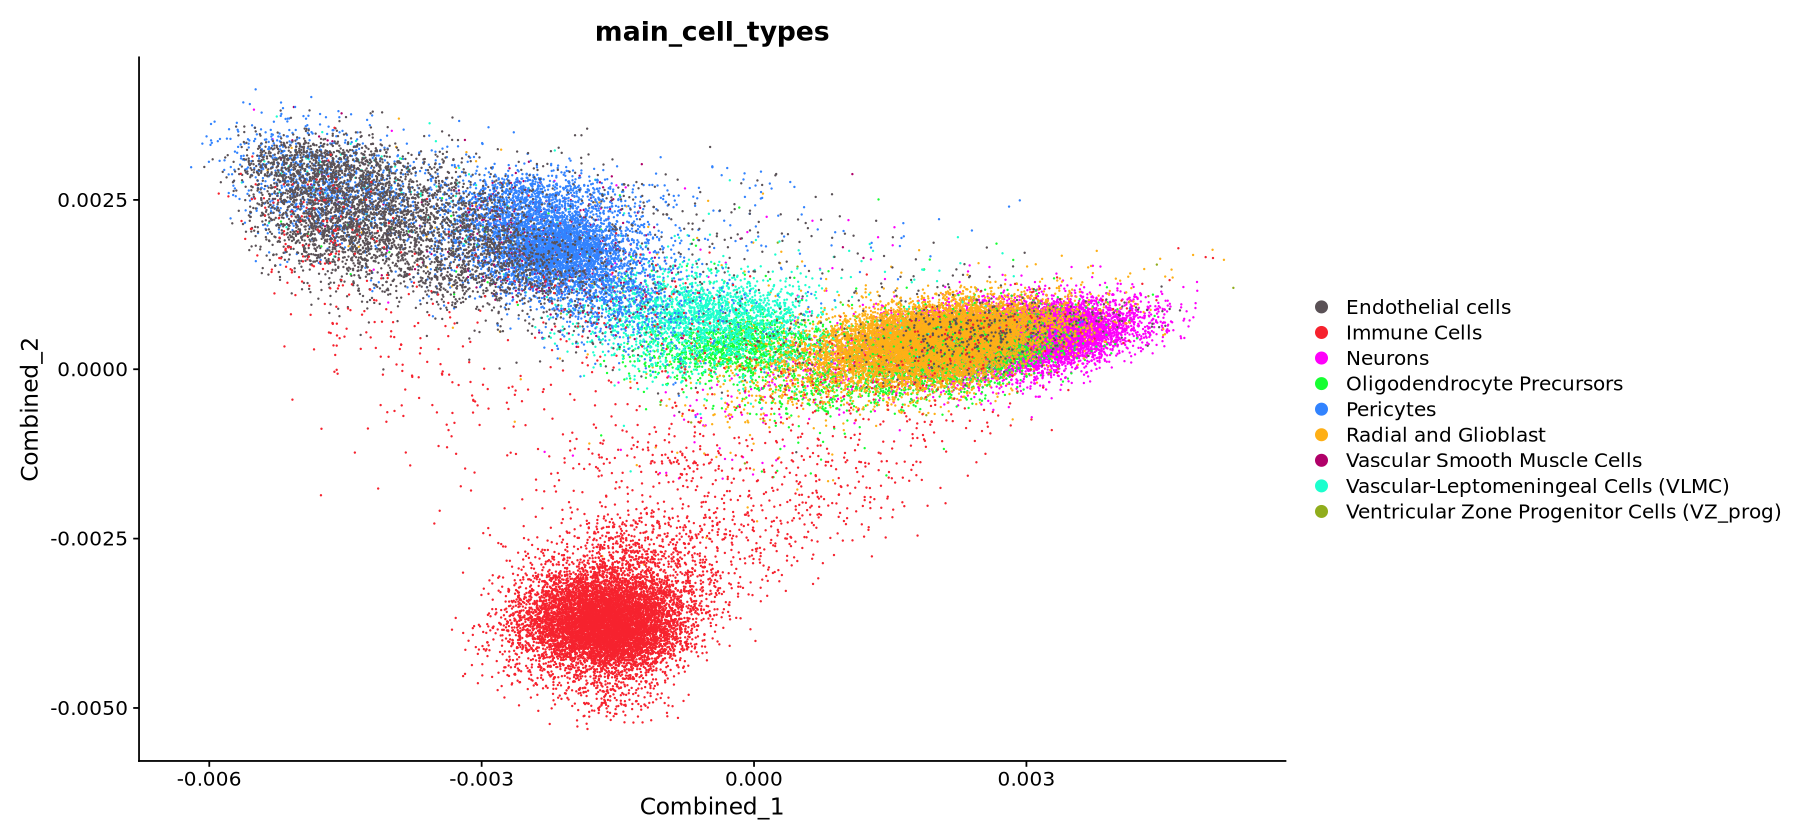

In [146]:
DimPlot(object = test, dims = 1:2, reduction = 'CombinedDims', group.by = 'main_cell_types', cols = my_colours)

In [152]:
test

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 6 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap, CombinedDims

In [155]:
test <- RunUMAP(
  object = test,
  reduction = "CombinedDims",
  assay = "RNA",
  dims = 1:30,  # Specify the number of dimensions
  verbose = TRUE
)

17:12:49 UMAP embedding parameters a = 0.9922 b = 1.112

17:12:49 Read 49470 rows and found 30 numeric columns

17:12:49 Using Annoy for neighbor search, n_neighbors = 30

17:12:49 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:12:58 Writing NN index file to temp file /tmp/RtmpuorRqP/filed186d4ab25b35

17:12:58 Searching Annoy index using 1 thread, search_k = 3000

17:13:16 Annoy recall = 100%

17:13:18 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:13:22 Initializing from normalized Laplacian + noise (using RSpectra)

17:13:28 Commencing optimization for 200 epochs, with 2163234 positive edges

17:14:00 Optimization finished



In [156]:
test

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 7 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap, CombinedDims, umap

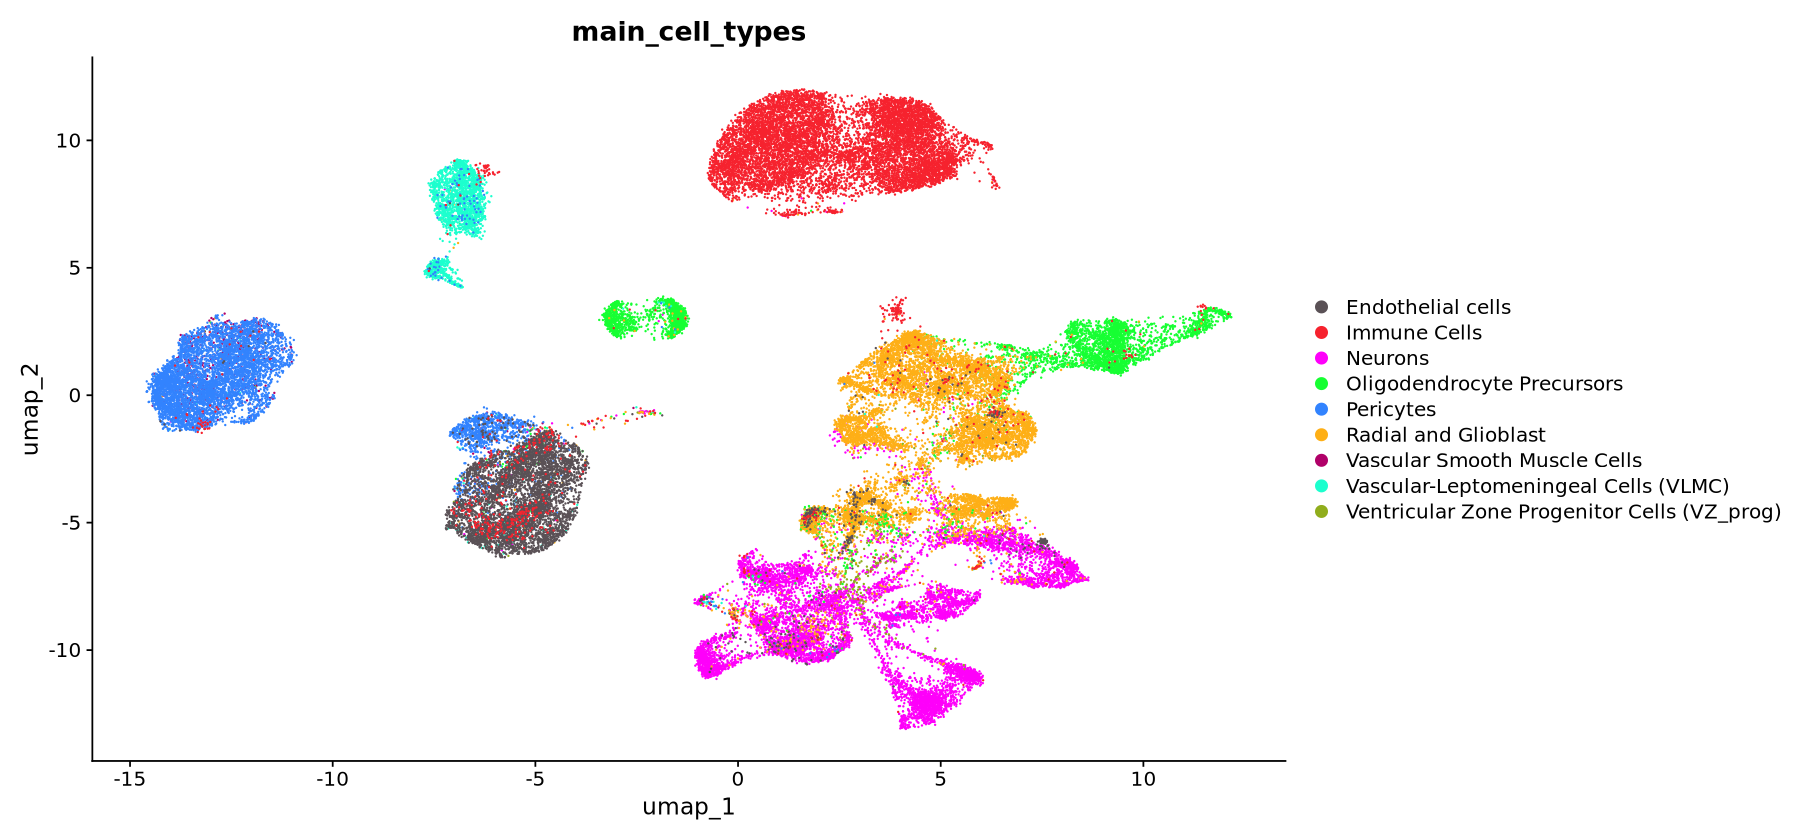

In [157]:
DimPlot(object = test, dims = 1:2, reduction = 'umap', group.by = 'main_cell_types', cols = my_colours)

In [159]:
# I will use the pca_atac embeddins in the epiregulon analysis.

In [160]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-unknown-linux-gnu
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gnu/store/mj1kw87qd3m1q7r4844adkn5hifx8k6a-openblas-0.3.20/lib/libopenblasp-r0.3.20.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C          LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C.UTF-8
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] BSgenome.Hsapiens.UCSC.hg38_1.4.5 BSgenome_1.74.0                  
 [3] rtracklayer_1.66.0                BiocIO_1.16.0                    
 [5] Biostrings_2.74.0                 XVector_0.46.0                   
 [7] GenomicRanges_1.58.0              GenomeInfoDb_